### <center style="color: maroon; font-size: 35px;"> African Institute for Mathematical Sciences</center>
<center><img src="https://aims.ac.rw/wp-content/uploads/sites/7/2020/10/AIMS-RWANDA-logo-PRINT-RGB-1024x189.jpg" alt="The San Juan Mountains are beautiful!" title="San Juan Mountains"></center>

# <center style="color: orange; font-size: 70px;"> Carbon Tax Simulator </center>

# <center style="color:black; font:40;">A personal presentation by</center>
# <center style="color:black; font:40;">Pearl Nibebadaar Sandoh Kuuridong</center>

# Introduction

According to this NASA [article](https://science.nasa.gov/climate-change/what-is-climate-change/), climate change refers to a long-term change in the average weather patterns of different regions on Earth. One of the main drivers of climate change is the increase in concentration of certain chemical compounds in the Earth's atmosphere. These include Carbon Dioxide (CO<sub>2</sub>), Methane (CH<sub>4</sub>), and Nitrous Oxide (N<sub>2</sub>O), usually known collectively as **greenhouse gases**. The increase in the concentration of these substances is warming our planet [[1]](https://science.nasa.gov/climate-change/causes/), which poses a serious risk to governments, scientists, and the whole human race.

<!-- How can I write that many companies are emitting these gases? -->
A significant portion of these greenhouse gases comes from human activities, particularly from large industrial companies in sectors such as fossil fuel production, manufacturing, and agriculture. For instance, in 2022, the U.S. transportation sector was responsible for 28.4% of greenhouse gas emissions, while electricity production accounted for 24.9%, and industry contributed 22.9% [[2]](https://usafacts.org/articles/what-are-the-main-sources-of-us-greenhouse-gas-emissions/). Globally, the energy sector, including electricity and heat production, is the largest emitter, accounting for over 70% of total emissions [[3]](https://www.wri.org/insights/4-charts-explain-greenhouse-gas-emissions-countries-and-sectors). These industries emit millions of tons of CO<sub>2</sub>, CH<sub>4</sub>, and N<sub>2</sub>O each year, making them key targets for policy interventions.

As a result, some governments, [like in Sweden and Finland](https://taxfoundation.org/research/all/eu/sweden-carbon-tax-revenue-greenhouse-gas-emissions/), have implemented **Carbon Taxes**, which are levies imposed on the emission of greenhouse gases, to encourage companies to produce less of these greenhouse gases.

This project presents a Carbon Tax Simulator, designed to explore how different tax rates, production outputs, and emission intensities affect total emissions and financial costs for firms. The simulator essentially gives a simplification of a typical end-to-end data engineering task.
<!-- The simulator allows users to experiment with various policy scenarios and visualize their potential impact, providing an interactive way to understand the dynamics of carbon taxation and its role in mitigating climate change. -->
<!-- Climate change is one of the most pressing global challenges of our time, driven largely by greenhouse gas emissions from industrial activity, transportation, and energy production. Governments worldwide are exploring mechanisms to reduce emissions and incentivize sustainable practices. One widely discussed policy tool is the carbon tax, which imposes a fee on the carbon content of fossil fuels. By attaching a cost to emissions, a carbon tax encourages firms and individuals to adopt cleaner technologies and reduce their carbon footprint.-->

# Documentation

In this section I give a brief description of each function and the function definition. The idea is for anyone to be able to use this notebook as a self-contained resource, and run this project end-to-end with little to no external help.

# Main Functions

**emissions function**:

`emissions` refers to the total amount of greenhouse gases a company produces during some time period. It is calculated by multiplying the `emissions_intensity`, which is the amount of greenhouse gas per unit, by the total `output`, which refers to the total number of units the company produces during some time period.

In [1]:
def emissions(output:float, emissions_intensity:float) -> float:
  """
  This function calculates and returns a firm's total emissions.

  Input
  ------------
  output: float
      The firm's total production level.
  emissions_intensity: float
      The amount of emissions per unit of output.

  Returns
  -----------
  float
      The total emissions produced by the firm.
  """
  return round(output*emissions_intensity, 2)

# Demonstration of `emissions` function

In [2]:
emissions(5.8, 0.5)

2.9

**tax_liability**

`tax_liability` refers to the total amount of money a company has to pay in carbon taxes. It is calculated by multiplying the `tax_rate`, which is the amount of money owed for a 1 ton of the greenhouse gases emitted, by the `total_emissions` emitted by a company.

In [3]:
def tax_liability(tax_rate:float, emissions:float) -> float:
  """
  This function calculates and returns a firm's carbon tax liability.

  Input
  ------------
  tax_rate: float
      The carbon tax rate applied per unit of emissions.
  emissions: float
      The firm's total emissions.

  Returns
  -----------
  float
      The total carbon tax owed by the firm.
  """
  return round(emissions*tax_rate,2)

# Demonstration of `tax_liability` function

In [4]:
tax_liability(5.8345, 0.255)

1.49

**profit_after_tax**

`profit_after_tax` refers to the net profit made by a single company, after the carbon tax. It is calculated by subtracting the `tax_liability` from the total `profit`.

In [5]:
def profit_after_tax(profit:float, tax_liability:float) -> float:
  """
  This function calculates and returns a firm's profit after paying the carbon tax.

  Input
  ------------
  tax_liability: float
      The carbon tax liability owed by a firm.
  profit: float
      The profit of the firm before the carbon tax.

  Returns
  -----------
  float
      The company's profit after paying for the carbon tax.
  """
  return round(profit-tax_liability, 2)

# Demonstration of `profit_after_tax` function

In [6]:
profit_after_tax(1_000_000_500, 2_300_500)

997700000

**generate_data**

The `generate_data` function is used to generate some random data which will be used for our dashboard. It creates a csv file which will later be read into the rest of our program for the dashboard. For this function some in-built  libraries were used and they are:

1. **csv**: Allows for easy creationg, handling and manipulation of csv files.


2. **string**: Allows for manipulation of strings in Python. For this project it was used to generate uppercase letters which were used in the generation of a firm ID.


3. **random**: Allows for generation of random data. For this project it was used to generate random data to populate some of the columns in the dataset.

In [7]:
import csv
import string
import random


def generate_data(output_path:str, nrows:int=100) -> bool:
  """
  This function simulates some company data in a CSV file.

  Input
  --------
  output_path: str
      The path to save the output CSV to.
  nrows: int
      The number of rows for your CSV file

  Returns
  --------
  bool
      True for success and False otherwise

  Output
  --------
    - Generates 10 unique firm IDs (a letter followed by a number between 1 and 26).
    - For each firm, randomly generates:
        - output (integer between 1000 and 10000)
        - emissions_intensity (float between 0 and 1, rounded to 2 decimals)
        - profit (float between 100,000 and 100,000,000, rounded to 2 decimals)
        - tax_rate (float between 100 and 1000, rounded to 2 decimals)
    - Writes the data to a CSV file with columns:
      'firm_id', 'output', 'emissions_intensity', 'profit', 'tax_rate', 'sector'
  """

  letters = list(string.ascii_uppercase)
  ids = set()
  sectors = ["Cement", "Metals", "Electricity", "Oil & Gas", "Transport"]

  while len(ids)<nrows:
    ids.add(''.join((random.choice(letters), str(random.randint(1, 26)))))

  try:
    with open(output_path, 'w', newline='') as file:
      writer = csv.DictWriter(file, fieldnames=['firm_id', 'output', 'emissions_intensity', 'profit', 'tax_rate', 'sector'])
      writer.writeheader()

      for id in ids:
        output = random.randint(1000, 10000)
        emissions_intensity = random.random()
        profit = random.uniform(100000, 100000000)
        tax_rate = random.uniform(100, 1000)
        sector = random.choice(sectors)
        writer.writerow({'firm_id': id,
                        'output': output,
                        'emissions_intensity': round(emissions_intensity, 2),
                        'profit': round(profit, 2),
                        'tax_rate': round(tax_rate, 2),
                        'sector': sector
                        })

  except Exception as e:
    print(f"Error: {e}")
    return False

  return True

# Demonstration of `generate_data` function

In [8]:
generate_data("./carbon_tax_data")

True

In [9]:
# !pip install pandas

In [10]:
import pandas as pd

**read_and_transform**

The `read_and_transform` function reads in the data file and creates the extra columns that will transform the raw data into some information that can be used for the dashboard.

In [11]:
def read_and_transform(filepath:str) -> pd.DataFrame:
  """
  The function reads firm-level data from a CSV file and computes the following
  derived columns: total_emissions, total_tax, and net_profit.

  Parameters
  ----------
  filepath : str
      Path to the CSV file containing firm data. The file must include the columns:
      'output', 'emissions_intensity', 'tax_rate', and 'profit' to be used in the calculations.

  Returns
  -------
  pandas.DataFrame
      A DataFrame containing the original data along with three new columns:
      - 'total_emissions' : float
          Total emissions produced by each firm.
      - 'total_tax' : float
          Total carbon tax owed by each firm.
      - 'net_profit' : float
          Profit after accounting for carbon tax.
  """
  data = pd.read_csv(filepath)

  data['total_emissions'] = data.apply(lambda row: emissions(row['output'], row['emissions_intensity']), axis=1)
  data['total_tax'] = data.apply(lambda row: tax_liability(row['tax_rate'], row['total_emissions']), axis=1)
  data['net_profit'] = data.apply(lambda row: profit_after_tax(row['profit'], row['total_tax']), axis=1)
  return data


In [12]:
input_data = read_and_transform("./carbon_tax_data")
input_data.head()

,firm_id,output,emissions_intensity,profit,tax_rate,sector,total_emissions,total_tax,net_profit
0,C3,1152,0.11,58652709.57,909.63,Cement,126.72,115268.31,58537441.26
1,G26,5308,0.33,44479509.67,916.30,Cement,1751.64,1605027.73,42874481.94
2,L22,7650,0.54,71646875.08,520.80,Cement,4131.00,2151424.80,69495450.28
3,I22,6676,0.57,30269830.52,619.87,Electricity,3805.32,2358803.71,27911026.81
4,O25,6935,0.99,83940140.62,947.52,Electricity,6865.65,6505340.69,77434799.93


# Dashboard

In [13]:
#!pip install matplotlib

In [14]:
import matplotlib.pyplot as plt

The `carbon_tax_dashboard` function generates a simple static dashboard for the given input data. The dashboard includes the following charts:

1. Histogram of total emissions across firms.
2. Bar chart showing average profit and net profit by industry sector.
3. Scatter plot of firm output vs total emissions, colored by emissions intensity.
4. Pie chart showing the share of total carbon tax paid by each sector.

In [15]:
def carbon_tax_dashboard(data: pd.DataFrame):
    """
    This function generates a static dashboard visualizing key metrics from a carbon tax simulation dataset.

    The dashboard consists of 4 subplots arranged in a 2x2 grid:
    1. Histogram of total emissions across firms.
    2. Bar chart showing average profit and net profit by industry sector.
    3. Scatter plot of firm output vs total emissions, colored by emissions intensity.
    4. Pie chart showing the share of total carbon tax paid by each sector.

    Parameters
    ----------
    data : pd.DataFrame
        A pandas DataFrame containing the following columns:
        - 'sector' : str
            Industry sector of the firm.
        - 'total_emissions' : float
            Total CO₂ emissions of the firm (in tons).
        - 'profit' : float
            Profit of the firm (in $).
        - 'net_profit' : float
            Net profit of the firm after taxes (in $).
        - 'output' : float
            Production output of the firm (in units or monetary value).
        - 'emissions_intensity' : float
            Emissions intensity of the firm (tons CO₂ per unit output).
        - 'total_tax' : float
            Total carbon tax paid by the firm (in $).

    """


    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("Carbon Tax Simulator Dashboard", fontsize=16, weight="bold")

    axes[0, 0].hist(data["total_emissions"], bins=20, color="skyblue", edgecolor="black")
    axes[0, 0].set_title("Distribution of Total Emissions")
    axes[0, 0].set_xlabel("Emissions (tons CO₂)")
    axes[0, 0].set_ylabel("Number of Firms")

    industry_stats = data.groupby("sector")[["profit", "net_profit"]].mean()
    industry_stats.plot(kind="bar", ax=axes[0, 1])
    axes[0, 1].set_title("Average Profit by Industry")
    axes[0, 1].set_ylabel("Profit ($)")
    axes[0, 1].tick_params(axis='x', rotation=0)

    sc = axes[1, 0].scatter(data["output"], data["total_emissions"], c=data["emissions_intensity"], cmap="viridis")
    axes[1, 0].set_title("Output vs Emissions")
    axes[1, 0].set_xlabel("Output")
    axes[1, 0].set_ylabel("Total Emissions")
    fig.colorbar(sc, ax=axes[1, 0], label="Emission Intensity")

    tax_by_industry = data.groupby("sector")["total_tax"].sum()
    axes[1, 1].pie(tax_by_industry, labels=tax_by_industry.index, autopct='%1.1f%%', startangle=90)
    axes[1, 1].set_title("Share of Total Carbon Tax Paid")

# Demonstration of `carbon_tax_dashboard` function

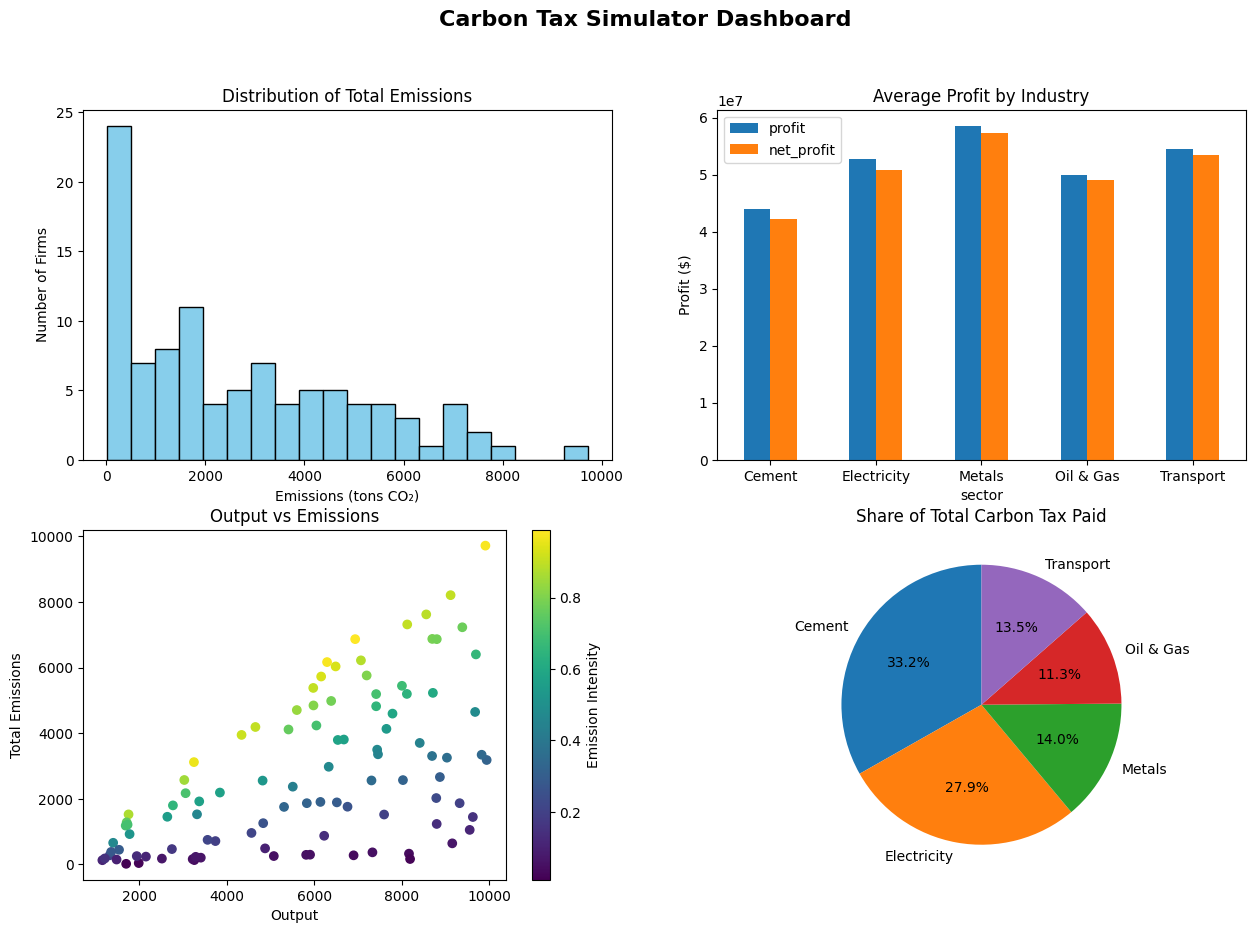

In [16]:
carbon_tax_dashboard(input_data)

In [17]:
!git status

On branch individual-presentation
Your branch is up to date with 'origin/individual-presentation'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   src/logic.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	../carbon-tax/
	.ipynb_checkpoints/
	another_trial.csv
	app.py
	carbon_tax_data
	output_file.csv
	pearl_kuuridong_personal_presentation.ipynb
	pearl_kuuridong_personal_presentation.py
	personal_presentation_pdf.pdf
	../skill_phase/block_2/

no changes added to commit (use "git add" and/or "git commit -a")


In [ ]:
!git add pearl_kuuridong_personal_presentation.ipynb